In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import sys
sys.path.append('..')
from src.nonlinear_sys import *
from src.cbf import *
from src.double_int import polytope, duality_filter

In [2]:
int_sys = DoubleIntegrator()

h = lambda x : 1 - x[0]*x[0] - x[1]*x[1] - x[0]*x[1]
dh = lambda x : np.array([-2*x[0]-x[1], -x[0]-2*x[1]])

cbf = CBF(1, h, dh, int_sys)
r_cbf = Rob_CBF(1, h, dh, int_sys, 0.2, 0.2)
r_cbf2 = Rob_CBF(1, h, dh, int_sys, 1, 1)

In [3]:
def create_cbf_plot():
    # Create a grid of points
    x1_vals = np.linspace(-2, 2, 400)
    x2_vals = np.linspace(-2, 2, 400)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)
    Z = h(np.array([X1, X2]))

    # Create the plot
    plt.figure(figsize=(6, 4), dpi=150)

    # Use contourf to fill the region where h(x) >= 0
    # The levels=[0, np.inf] tells matplotlib to fill everything from 0 upwards
    plt.contourf(X1, X2, Z, levels=[0, np.inf], colors=["#ade6be"], alpha=0.6)
    plt.contourf(X1, X2, Z, levels=[-np.inf, 0], colors=["#e6adad"], alpha=0.6)

    # Use contour to draw the boundary line (h(x) = 0)
    plt.contour(X1, X2, Z, levels=[0], colors=['green'], linewidths=2)

In [4]:
t_end = 10
t = np.linspace(0, t_end, 1001)

x0 = np.array([1, -0.5])
delta = np.array([0.08, 0.08])

mr_cbf = MR_CBF(1, h, dh, int_sys, np.linalg.norm(delta), 3, np.sqrt(5), 3)

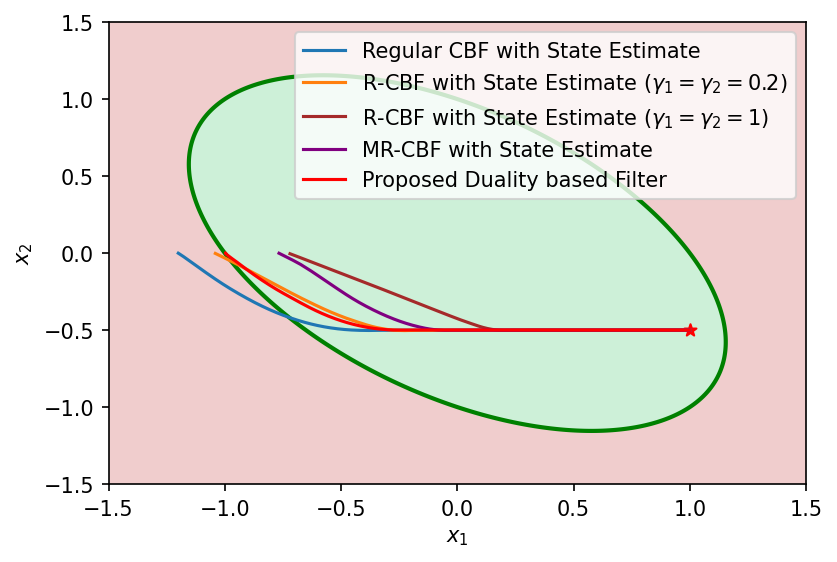

In [5]:
trajs = solve_ivp(lambda t, y: int_sys.RHS(y, cbf.filter(y + delta, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
trajs_rcbf = solve_ivp(lambda t, y: int_sys.RHS(y, r_cbf.filter(y + delta, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
trajs_rcbf2 = solve_ivp(lambda t, y: int_sys.RHS(y, r_cbf2.filter(y + delta, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
trajs_rob = solve_ivp(lambda t, y: int_sys.RHS(y, duality_filter(y+delta, delta)), (0, t_end), x0, method='RK45', t_eval=t).y
trajs_mrcbf = solve_ivp(lambda t, y : int_sys.RHS(y, mr_cbf.filter(y + delta, 0)), (0, t_end), x0, method='RK45', t_eval=t).y

create_cbf_plot()
plt.scatter(x0[0], x0[1], marker='*', color='red')
plt.plot(trajs[0], trajs[1], label="Regular CBF with State Estimate")
plt.plot(trajs_rcbf[0], trajs_rcbf[1], label="R-CBF with State Estimate ($\\gamma_1=\\gamma_2=0.2$)")
plt.plot(trajs_rcbf2[0], trajs_rcbf2[1], label="R-CBF with State Estimate ($\\gamma_1=\\gamma_2=1$)", color="brown")
# plt.plot(trajs[0]+delta[0], trajs[1]+delta[1], label="Estimated State")
plt.plot(trajs_mrcbf[0], trajs_mrcbf[1], label="MR-CBF with State Estimate", color="purple")
plt.plot(trajs_rob[0], trajs_rob[1], label="Proposed Duality based Filter", color="red")

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.show()

MR-CBF infeasible for d=0.12
MR-CBF infeasible for d=0.15
MR-CBF infeasible for d=0.18
MR-CBF infeasible for d=0.21
MR-CBF infeasible for d=0.24
MR-CBF infeasible for d=0.27
MR-CBF infeasible for d=0.3


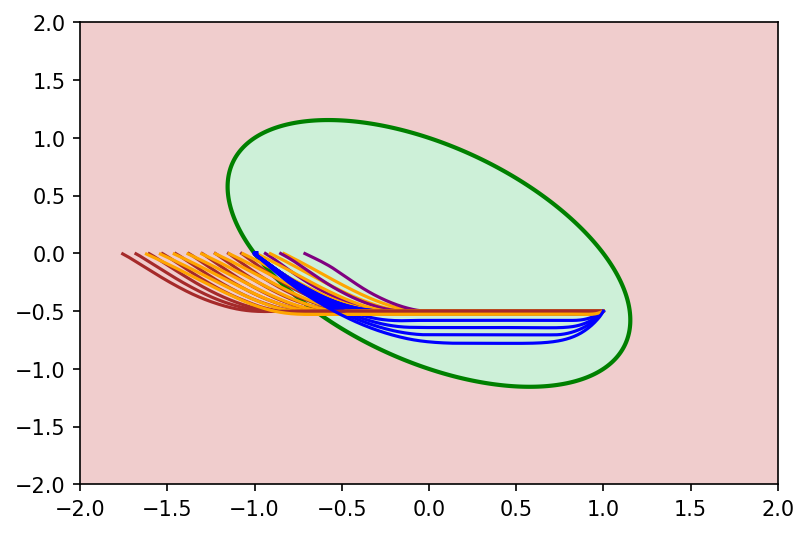

In [6]:
deltas = np.linspace(0, 0.3, 11)

h_min_cbf = np.zeros_like(deltas)
h_min_rcbf = np.zeros_like(deltas)
h_min_rcbf2 = np.zeros_like(deltas)
h_min_dual = np.zeros_like(deltas)
h_min_mrcbf = np.zeros_like(deltas)

create_cbf_plot()
for i, delta_i in enumerate(deltas):
    frac = delta_i/deltas[-1]
    delta_i = np.ones(2)*delta_i
    trajs = solve_ivp(lambda t, y: int_sys.RHS(y, cbf.filter(y + delta_i, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
    trajs_rob = solve_ivp(lambda t, y: int_sys.RHS(y, duality_filter(y + delta_i, delta_i)), (0, t_end), x0, method='RK45', t_eval=t).y
    trajs_rcbf = solve_ivp(lambda t, y: int_sys.RHS(y, r_cbf.filter(y + delta_i, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
    trajs_rcbf2 = solve_ivp(lambda t, y: int_sys.RHS(y, r_cbf2.filter(y + delta_i, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
    try:
        mr_cbf.d = np.linalg.norm(delta_i)
        trajs_mrcbf = solve_ivp(lambda t, y : int_sys.RHS(y, mr_cbf.filter(y + delta_i, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
        h_min_mrcbf[i] = np.min(h(trajs_mrcbf))
        plt.plot(trajs_mrcbf[0], trajs_mrcbf[1], color='purple')
    except Exception as e:
        print(f"MR-CBF infeasible for d={deltas[i]}")
        h_min_mrcbf[i] = None

    plt.plot(trajs[0], trajs[1], color='brown')
    plt.plot(trajs_rcbf[0], trajs_rcbf[1], color='orange')
    plt.plot(trajs_rob[0], trajs_rob[1], color="blue")

    h_min_cbf[i] = np.min(h(trajs))
    h_min_rcbf[i] = np.min(h(trajs_rcbf))
    h_min_rcbf2[i] = np.min(h(trajs_rcbf2))
    h_min_dual[i] = np.min(h(trajs_rob))

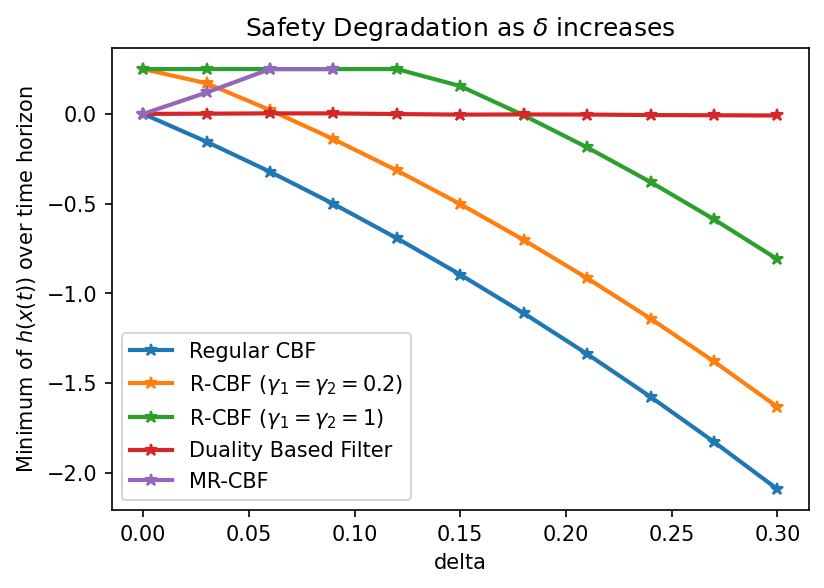

In [7]:
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(deltas, h_min_cbf, label="Regular CBF", lw=2, marker='*')
plt.plot(deltas, h_min_rcbf, label="R-CBF ($\\gamma_1=\\gamma_2=0.2$)", lw=2, marker='*')
plt.plot(deltas, h_min_rcbf2, label="R-CBF ($\\gamma_1=\\gamma_2=1$)", lw=2, marker='*')
plt.plot(deltas, h_min_dual, label="Duality Based Filter", lw=2, marker='*')
plt.plot(deltas, h_min_mrcbf, label="MR-CBF", lw=2, marker='*')

plt.legend()
plt.xlabel("delta")
plt.ylabel("Minimum of $h(x(t))$ over time horizon")
plt.title("Safety Degradation as $\\delta$ increases")
plt.show()

## Multiple Initial Conditions

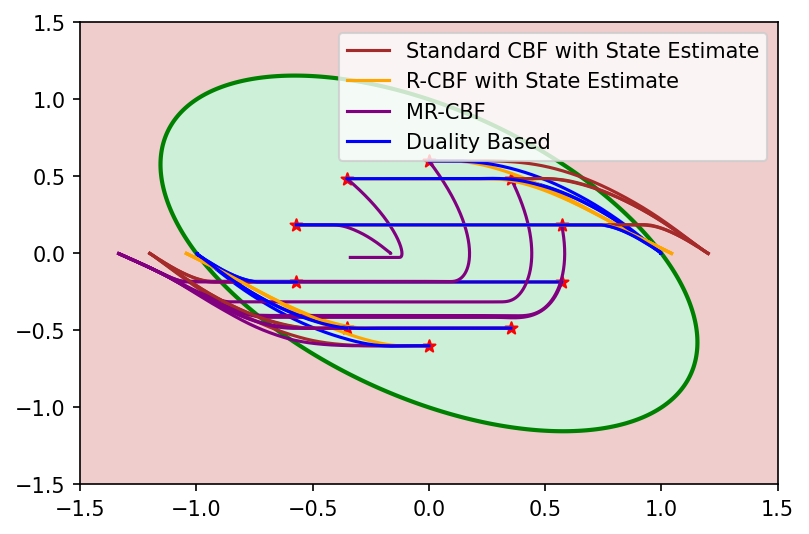

In [8]:
N_test_points = 10
r = 0.6

# Function for Adverserial Noise
def err(x):
    return delta if x[0]<0 else -delta

thetas = np.linspace(-np.pi/2, 3*np.pi/2, N_test_points, endpoint=False)

create_cbf_plot()
for i,theta in enumerate(thetas):
    x0 = np.array([r*np.cos(theta), r*np.sin(theta)])
    
    trajs = solve_ivp(lambda t, y: int_sys.RHS(y, cbf.filter(y + err(y), 0)), (0, t_end), x0, method='RK45', t_eval=t).y
    trajs_rob = solve_ivp(lambda t, y: int_sys.RHS(y, duality_filter(y + err(y), delta)), (0, t_end), x0, method='RK45', t_eval=t).y
    trajs_rcbf = solve_ivp(lambda t, y: int_sys.RHS(y, r_cbf.filter(y + err(y), 0)), (0, t_end), x0, method='RK45', t_eval=t).y
    mr_cbf.d = np.linalg.norm(delta)
    try:
        trajs_mrcbf = solve_ivp(lambda t, y : int_sys.RHS(y, mr_cbf.filter(y + delta_i, 0)), (0, t_end), x0, method='RK45', t_eval=t).y
    except:
        pass

    plt.plot(trajs[0], trajs[1], color='brown', label="Standard CBF with State Estimate" if i==0 else None)
    plt.plot(trajs_rcbf[0], trajs_rcbf[1], color='orange', label="R-CBF with State Estimate" if i==0 else None)
    plt.plot(trajs_mrcbf[0], trajs_mrcbf[1], color='purple', label="MR-CBF" if i==0 else None)
    plt.plot(trajs_rob[0], trajs_rob[1], color="blue", label="Duality Based" if i==0 else None)
    
    plt.scatter(x0[0], x0[1], marker='*', color='red')

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
plt.legend()
plt.show()
    